Importing the necessary libraries


In [ ]:
# Libraries to help with reading and manipulating data
from pathlib import Path
import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportion_confint, proportions_ztest
from great_tables import GT, loc, style

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# to restrict the float value to 3 decimal places
pd.set_option('display.float_format', lambda x: '%.3f' % x)

Importing the dataset

In [ ]:
# Load the raw validation workbook stored on the shared G: drive
data_path = Path("G:/Documents/Research/Projects/moo/llm_summary/data/raw/merged_llm_summary_validation_datasheet.xlsx")
data = pd.read_excel(data_path)

Understand the data

In [ ]:
data.head()

,Unnamed: 0,surgeon,mrn,patient_initials,tumor_invasive_dcis,complex_case_status,lesion_size_status_source,lesion_size_status_human,lesion_size_status_ai,laterality_status_source,...,invasive_component_size_pathology_status_source,invasive_component_size_pathology_status_human,invasive_component_size_pathology_status_ai,histologic_diagnosis_status_source,histologic_diagnosis_status_human,histologic_diagnosis_status_ai,receptor_status_source,receptor_status_human,receptor_status_ai,comments
0,22,"Bayard, Solange",39106341,SS,1,0,1,1,1,1,...,1,1,1,1,1,1,0,NaN,NaN,NaN
1,30,"Bayard, Solange",38285455,DP,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,Clip type reported on human HPI but not in sou...
2,180,"Plitas, George",39095083,YT,1,0,1,1,1,1,...,1,1,1,1,1,2,1,1,2,NaN
3,183,"Sacchini, Virgilio",39091785,SB,1,0,1,1,1,1,...,1,1,1,1,1,2,1,1,1,bot incorrectly labels MRI as unilateral and d...
4,187,"Sacchini, Virgilio",39100180,SB,1,0,1,1,1,1,...,1,1,1,1,1,2,1,1,1,bot doesn’t mention LCIS in histologic diagnosis


In [ ]:
data.shape

(200, 49)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Unnamed: 0                                       200 non-null    int64  
 1   surgeon                                          200 non-null    object 
 2   mrn                                              200 non-null    int64  
 3   patient_initials                                 200 non-null    object 
 4   tumor_invasive_dcis                              200 non-null    int64  
 5   complex_case_status                              200 non-null    int64  
 6   lesion_size_status_source                        200 non-null    int64  
 7   lesion_size_status_human                         198 non-null    object 
 8   lesion_size_status_ai                            198 non-null    object 
 9   laterality_status_source        

In [ ]:

data['lesion_size_status_source'].unique()

array([1, 0])

In [ ]:
data['lesion_size_status_source'].value_counts()

lesion_size_status_source
1    196
0      4
Name: count, dtype: int64

In [ ]:
data['lesion_location_status_human'].value_counts()

lesion_location_status_human
1.000    196
2.000      3
Name: count, dtype: int64

Handle Missing Values

In [ ]:
# Convert common placeholder strings to actual missing values across the DataFrame
missing_placeholders = ['na', 'NA', 'N/A']
data.replace(to_replace=missing_placeholders, value=np.nan, inplace=True)

C:\Users\jamesr4\AppData\Local\Temp\ipykernel_25972\2405881479.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace(to_replace=missing_placeholders, value=np.nan, inplace=True)


In [ ]:
# Data not present in source documents, hence missing in both human and AI annotations
data.isnull().sum()

Unnamed: 0                                           0
surgeon                                              0
mrn                                                  0
patient_initials                                     0
tumor_invasive_dcis                                  0
complex_case_status                                  0
lesion_size_status_source                            0
lesion_size_status_human                             4
lesion_size_status_ai                                4
laterality_status_source                             0
laterality_status_human                              0
laterality_status_ai                                 0
lesion_location_status_source                        0
lesion_location_status_human                         1
lesion_location_status_ai                            1
calcifications_asymmetry_status_source               0
calcifications_asymmetry_status_human               73
calcifications_asymmetry_status_ai                  73
additional

In [ ]:
# Drop rows where human and AI annotations are null, in other words not present in source
data = data.dropna()



Encode variables 

Accuracy metric calculations

In [ ]:
# Proportion of lesion size annotations by humans that is accurate
source_presence_lesion_size = (data['lesion_size_status_source'] == 1).sum()
human_lesion_size_annotation = (data['lesion_size_status_human'] == 1).sum()
lesion_size_human_accuracy = human_lesion_size_annotation / source_presence_lesion_size

In [ ]:

# Proportion of lesions size annotations by ai that is accurate
source_presence_lesion_size = (data['lesion_size_status_source'] == 1).sum()
ai_lesion_size_annotation = (data['lesion_size_status_ai'] == 1).sum()
lesion_size_ai_accuracy = ai_lesion_size_annotation / source_presence_lesion_size

In [ ]:
# Proportion of lesion laterality annotations by humans that is accurate
source_presence_lesion_laterality  = (data['laterality_status_source'] == 1).sum()
human_lesion_laterality_annotation = (data['laterality_status_human'] == 1).sum()
lesion_laterality_human_accuracy = human_lesion_laterality_annotation / source_presence_lesion_laterality

In [ ]:
# Proportion of lesion laterality annotations by ai that is accurate
source_presence_lesion_laterality  = (data['laterality_status_source'] == 1).sum()
ai_lesion_laterality_annotation = (data['laterality_status_ai'] == 1).sum()
lesion_laterality_ai_accuracy = ai_lesion_laterality_annotation / source_presence_lesion_laterality

In [ ]:
# Proportion of lesion location annotations by humans that is accurate

source_presence_lesion_location = (data['lesion_location_status_source'] == 1).sum()
human_lesion_annotation = (data['lesion_location_status_human'] == 1).sum()
lesion_location_human_accuracy = human_lesion_annotation / source_presence_lesion_location

In [ ]:
# Proportion of lesion location annotations by AI that is accurate

source_presence_lesion_location = (data['lesion_location_status_source'] == 1).sum()
ai_lesion_annotation = (data['lesion_location_status_ai'] == 1).sum()
lesion_location_ai_accuracy = ai_lesion_annotation / source_presence_lesion_location

In [ ]:
# Proportion of calcifications and asymmetry annotations by humans that is accurate
source_presence_calcifications_asymmetry = (data['calcifications_asymmetry_status_source'] == 1).sum()
human_calcifications_asymmetry_annotation = (data['calcifications_asymmetry_status_human'] == 1).sum()
calcifications_asymmetry_human_accuracy = human_calcifications_asymmetry_annotation / source_presence_calcifications_asymmetry

In [ ]:
# Proportion of calcifications and asymmetry annotations by ai that is accurate
source_presence_calcifications_asymmetry = (data['calcifications_asymmetry_status_source'] == 1).sum()
ai_calcifications_asymmetry_annotation = (data['calcifications_asymmetry_status_ai'] == 1).sum()
calcifications_asymmetry_ai_accuracy = ai_calcifications_asymmetry_annotation / source_presence_calcifications_asymmetry

In [ ]:
# Proportion of enhancement pattern annotations by humans that is accurate
source_presence_enhancement_pattern = (data['additional_enhancement_mri_status_source'] == 1).sum()
human_enhancement_pattern_annotation = (data['additional_enhancement_mri_status_human'] == 1).sum()
enhancement_pattern_human_accuracy = human_enhancement_pattern_annotation / source_presence_enhancement_pattern     

In [ ]:
# Proportion of enhancement pattern annotations by ai that is accurate
source_presence_enhancement_pattern = (data['additional_enhancement_mri_status_source'] == 1).sum()
ai_enhancement_pattern_annotation = (data['additional_enhancement_mri_status_ai'] == 1).sum()
enhancement_pattern_ai_accuracy = ai_enhancement_pattern_annotation / source_presence_enhancement_pattern   

In [ ]:
# Proportion of enhancement extent annotations by humans that is accurate
source_presence_enhancement_extent = (data['extent_status_source'] == 1).sum()
human_enhancement_extent_annotation = (data['extent_status_human'] == 1).sum()
enhancement_extent_human_accuracy = human_enhancement_extent_annotation / source_presence_enhancement_extent        

In [ ]:
# Proportion of enhancement extent annotations by ai that is accurate
source_presence_enhancement_extent = (data['extent_status_source'] == 1).sum()
ai_enhancement_extent_annotation = (data['extent_status_ai'] == 1).sum()
enhancement_extent_ai_accuracy = ai_enhancement_extent_annotation / source_presence_enhancement_extent      

In [ ]:
# Proportion of clip placement annotations by humans that is accurate
source_presence_clip_placement = (data['accurate_clip_placement_status_source'] == 1).sum()
human_clip_placement_annotation = (data['accurate_clip_placement_status_human'] == 1).sum()
clip_placement_human_accuracy = human_clip_placement_annotation / source_presence_clip_placement

In [ ]:
# Proportion of clip placement annotation by ai that is accurate
source_presence_clip_placement = (data['accurate_clip_placement_status_source'] == 1).sum()
ai_clip_placement_annotation = (data['accurate_clip_placement_status_ai'] == 1).sum()
clip_placement_ai_accuracy = ai_clip_placement_annotation / source_presence_clip_placement

In [ ]:
# Proportion of workup recommendations annotated by humans that is accurate
source_presence_workup_recommendation = (data['workup_recommendation_status_source'] == 1).sum()
human_workup_recommendation_annotation = (data['workup_recommendation_status_human'] == 1).sum()
workup_recommendation_human_accuracy = human_workup_recommendation_annotation / source_presence_workup_recommendation

In [ ]:
# Proportion of workup recommendations annotated by ai that is accurate
source_presence_workup_recommendation = (data['workup_recommendation_status_source'] == 1).sum()
ai_workup_recommendation_annotation = (data['workup_recommendation_status_ai'] == 1).sum()
workup_recommendation_ai_accuracy = ai_workup_recommendation_annotation / source_presence_workup_recommendation

In [ ]:
# Proportion of lymph node status annotations by humans that is accurate
source_presence_lymph_node_status = (data['Lymph node_status_source'] == 1).sum()
human_lymph_node_status_annotation = (data['Lymph node_status_human'] == 1).sum()
lymph_node_status_human_accuracy = human_lymph_node_status_annotation / source_presence_lymph_node_status

In [ ]:
# Proportion of lymph node status annotations by ai that is accurate
source_presence_lymph_node_status = (data['Lymph node_status_source'] == 1).sum()
ai_lymph_node_status_annotation = (data['Lymph node_status_ai'] == 1).sum()
lymph_node_status_ai_accuracy = ai_lymph_node_status_annotation / source_presence_lymph_node_status

In [ ]:
# Proportion of breast oncologic timelines by humans that is accurate
source_presence_breast_oncologic_timeline = (data['chronology_preserved_status_source'] == 1).sum()
human_breast_oncologic_timeline_annotation = (data['chronology_preserved_status_human'] == 1).sum()
breast_oncologic_timeline_human_accuracy = human_breast_oncologic_timeline_annotation / source_presence_breast_oncologic_timeline   

In [ ]:
# Proportion of breast oncologic timelines by ai that is accurate   
source_presence_breast_oncologic_timeline = (data['chronology_preserved_status_source'] == 1).sum() 
ai_breast_oncologic_timeline_annotation = (data['chronology_preserved_status_ai'] == 1).sum()
breast_oncologic_timeline_ai_accuracy = ai_breast_oncologic_timeline_annotation / source_presence_breast_oncologic_timeline 

In [ ]:
# Proportion of biopsy method annotations by humans that is accurate
source_presence_biopsy_method = (data['biopsy_method_status_source'] == 1).sum()
human_biopsy_method_annotation = (data['biopsy_method_status_human'] == 1).sum()
biopsy_method_human_accuracy = human_biopsy_method_annotation / source_presence_biopsy_method

In [ ]:
# Proportion of biopsy method annotations by ai that is accurate
source_presence_biopsy_method = (data['biopsy_method_status_source'] == 1).sum()
ai_biopsy_method_annotation = (data['biopsy_method_status_ai'] == 1).sum()
biopsy_method_ai_accuracy = ai_biopsy_method_annotation / source_presence_biopsy_method 

In [ ]:
# Proportion of invasive component size annotations by humans that is accurate
source_presence_invasive_component = (data['invasive_component_size_pathology_status_source'] == 1).sum()
human_invasive_component_annotation = (data['invasive_component_size_pathology_status_human'] == 1).sum()
invasive_component_human_accuracy = human_invasive_component_annotation / source_presence_invasive_component

In [ ]:
# Proportion of invasive component size annotations by ai that is accurate
source_presence_invasive_component = (data['invasive_component_size_pathology_status_source'] == 1).sum()
ai_invasive_component_annotation = (data['invasive_component_size_pathology_status_ai'] == 1).sum()
invasive_component_ai_accuracy = ai_invasive_component_annotation / source_presence_invasive_component  

In [ ]:
# Proportion of histologic diagnosis annotations by humans that is accurate
source_presence_histologic_diagnosis = (data['histologic_diagnosis_status_source'] == 1).sum()
human_histologic_diagnosis_annotation = (data['histologic_diagnosis_status_human'] == 1).sum()
histologic_diagnosis_human_accuracy = human_histologic_diagnosis_annotation / source_presence_histologic_diagnosis  

In [ ]:
# Proportion of histologic diagnosis annotations by ai that is accurate
source_presence_histologic_diagnosis = (data['histologic_diagnosis_status_source'] == 1).sum()  
ai_histologic_diagnosis_annotation = (data['histologic_diagnosis_status_ai'] == 1).sum()    
histologic_diagnosis_ai_accuracy = ai_histologic_diagnosis_annotation / source_presence_histologic_diagnosis    

In [ ]:
# Proportion of receptor status annotations by humans that is accurate
source_presence_receptor_status = (data['receptor_status_source'] == 1).sum()
human_receptor_status_annotation = (data['receptor_status_human'] == 1).sum()
receptor_status_human_accuracy = human_receptor_status_annotation / source_presence_receptor_status 

In [ ]:
# Proportion of receptor status annotation by ai that is accurate
source_presence_receptor_status = (data['receptor_status_source'] == 1).sum()
ai_receptor_status_annotation = (data['receptor_status_ai'] == 1).sum()
receptor_status_ai_accuracy = ai_receptor_status_annotation / source_presence_receptor_status   

Accuracy metric summary for human vs ai 

In [ ]:
# Human and AI element-level accuracies summarized in one table
data_human_accuracy_element_level = {
    'Lesion size': lesion_size_human_accuracy,
    'Lesion laterality': lesion_laterality_human_accuracy,
    'Lesion location': lesion_location_human_accuracy,
    'Calcifications and asymmetry': calcifications_asymmetry_human_accuracy,
    'Enhancement pattern': enhancement_pattern_human_accuracy,
    'Enhancement extent': enhancement_extent_human_accuracy,
    'Clip placement and displacement': clip_placement_human_accuracy,
    'Workup recommendations': workup_recommendation_human_accuracy,
    'Lymph node status': lymph_node_status_human_accuracy,
    'Breast oncologic timeline': breast_oncologic_timeline_human_accuracy,
    'Biopsy method': biopsy_method_human_accuracy,
    'Invasive component': invasive_component_human_accuracy,
    'Histologic diagnosis': histologic_diagnosis_human_accuracy,
    'Receptor status': receptor_status_human_accuracy
}

data_ai_accuracy_element_level = {
    'Lesion size': lesion_size_ai_accuracy,
    'Lesion laterality': lesion_laterality_ai_accuracy,
    'Lesion location': lesion_location_ai_accuracy,
    'Calcifications and asymmetry': calcifications_asymmetry_ai_accuracy,
    'Enhancement pattern': enhancement_pattern_ai_accuracy,
    'Enhancement extent': enhancement_extent_ai_accuracy,
    'Clip placement and displacement': clip_placement_ai_accuracy,
    'Workup recommendations': workup_recommendation_ai_accuracy,
    'Lymph node status': lymph_node_status_ai_accuracy,
    'Breast oncologic timeline': breast_oncologic_timeline_ai_accuracy,
    'Biopsy method': biopsy_method_ai_accuracy,
    'Invasive component': invasive_component_ai_accuracy,
    'Histologic diagnosis': histologic_diagnosis_ai_accuracy,
    'Receptor status': receptor_status_ai_accuracy
}

df_human_ai_element_accuracy = (
    pd.DataFrame.from_dict(
        data_human_accuracy_element_level, orient='index', columns=['Human Accuracy']
    )
    .join(
        pd.DataFrame.from_dict(
            data_ai_accuracy_element_level, orient='index', columns=['AI Accuracy']
        )
    )
    .rename_axis('Element')
    .reset_index()
 )

df_human_ai_element_accuracy

,Element,Human Accuracy,AI Accuracy
0,Lesion size,1.000,0.875
1,Lesion laterality,1.000,1.000
2,Lesion location,1.000,1.000
3,Calcifications and asymmetry,0.875,0.875
4,Enhancement pattern,0.625,1.000
5,Enhancement extent,0.625,1.000
6,Clip placement and displacement,0.875,1.000
7,Workup recommendations,0.625,0.875
8,Lymph node status,0.750,0.625
9,Breast oncologic timeline,1.000,1.000


In [ ]:
# Hypothesis tests and confidence intervals (95%) for human vs. AI element accuracy using McNemar's test and adjusted Wald CIs
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.proportion import confint_proportions_2indep
def adjusted_wald_ci(successes, n, alpha=0.05):
    # Agresti–Coull (adjusted Wald) interval for binomial proportion
    if n == 0:
        return (float('nan'), float('nan'))
    z = 1.96  # for 95% CI
    n_adj = n + z**2
    p_adj = (successes + 0.5 * z**2) / n_adj
    se_adj = (p_adj * (1 - p_adj) / n_adj) ** 0.5
    lower = p_adj - z * se_adj
    upper = p_adj + z * se_adj
    return max(0, lower), min(1, upper)

records = []
element_keys = [
    ('Lesion size', human_lesion_size_annotation, ai_lesion_size_annotation, source_presence_lesion_size),
    ('Lesion laterality', human_lesion_laterality_annotation, ai_lesion_laterality_annotation, source_presence_lesion_laterality),
    ('Lesion location', human_lesion_annotation, ai_lesion_annotation, source_presence_lesion_location),
    ('Calcifications and asymmetry', human_calcifications_asymmetry_annotation, ai_calcifications_asymmetry_annotation, source_presence_calcifications_asymmetry),
    ('Enhancement pattern', human_enhancement_pattern_annotation, ai_enhancement_pattern_annotation, source_presence_enhancement_pattern),
    ('Enhancement extent', human_enhancement_extent_annotation, ai_enhancement_extent_annotation, source_presence_enhancement_extent),
    ('Clip placement and displacement', human_clip_placement_annotation, ai_clip_placement_annotation, source_presence_clip_placement),
    ('Workup recommendations', human_workup_recommendation_annotation, ai_workup_recommendation_annotation, source_presence_workup_recommendation),
    ('Lymph node status', human_lymph_node_status_annotation, ai_lymph_node_status_annotation, source_presence_lymph_node_status),
    ('Breast oncologic timeline', human_breast_oncologic_timeline_annotation, ai_breast_oncologic_timeline_annotation, source_presence_breast_oncologic_timeline),
    ('Biopsy method', human_biopsy_method_annotation, ai_biopsy_method_annotation, source_presence_biopsy_method),
    ('Invasive component', human_invasive_component_annotation, ai_invasive_component_annotation, source_presence_invasive_component),
    ('Histologic diagnosis', human_histologic_diagnosis_annotation, ai_histologic_diagnosis_annotation, source_presence_histologic_diagnosis),
    ('Receptor status', human_receptor_status_annotation, ai_receptor_status_annotation, source_presence_receptor_status),
]
for element, human_success, ai_success, total in element_keys:
    if total == 0:
        continue
    # Adjusted Wald CIs for each proportion
    human_ci = adjusted_wald_ci(human_success, total)
    ai_ci = adjusted_wald_ci(ai_success, total)
    # McNemar's test for paired binary outcomes
    human_col = f'{element.lower().replace(" ", "_")}_status_human'
    ai_col = f'{element.lower().replace(" ", "_")}_status_ai'
    mask = data[[human_col, ai_col]].notnull().all(axis=1)
    if mask.sum() == 0:
        p_value = float('nan')
    else:
        human_bin = data.loc[mask, human_col].astype(int)
        ai_bin = data.loc[mask, ai_col].astype(int)
        table = pd.crosstab(human_bin, ai_bin).reindex(index=[0,1], columns=[0,1], fill_value=0)
        result = mcnemar(table, exact=mask.sum() < 25)
        p_value = result.pvalue
    records.append({
        'Element': element,
        'Human Accuracy': human_success / total,
        'AI Accuracy': ai_success / total,
        'Human 95% CI': f"({human_ci[0]:.3f}, {human_ci[1]:.3f})",
        'AI 95% CI': f"({ai_ci[0]:.3f}, {ai_ci[1]:.3f})",
        'Human CI Low': human_ci[0],
        'Human CI High': human_ci[1],
        'AI CI Low': ai_ci[0],
        'AI CI High': ai_ci[1],
        'p_value (McNemar)': p_value,
    })

df_accuracy_tests = pd.DataFrame(records)
df_accuracy_tests

,Element,Human Accuracy,AI Accuracy,Human 95% CI,AI 95% CI,Human CI Low,Human CI High,AI CI Low,AI CI High,p_value (H0: equal accuracy)
0,Lesion size,1.000,0.875,"(0.676, 1.000)","(0.529, 0.978)",0.676,1.000,0.529,0.978,0.302
1,Lesion laterality,1.000,1.000,"(0.676, 1.000)","(0.676, 1.000)",0.676,1.000,0.676,1.000,NaN
2,Lesion location,1.000,1.000,"(0.676, 1.000)","(0.676, 1.000)",0.676,1.000,0.676,1.000,NaN
3,Calcifications and asymmetry,0.875,0.875,"(0.529, 0.978)","(0.529, 0.978)",0.529,0.978,0.529,0.978,1.000
4,Enhancement pattern,0.625,1.000,"(0.306, 0.863)","(0.676, 1.000)",0.306,0.863,0.676,1.000,0.055
5,Enhancement extent,0.625,1.000,"(0.306, 0.863)","(0.676, 1.000)",0.306,0.863,0.676,1.000,0.055
6,Clip placement and displacement,0.875,1.000,"(0.529, 0.978)","(0.676, 1.000)",0.529,0.978,0.676,1.000,0.302
7,Workup recommendations,0.625,0.875,"(0.306, 0.863)","(0.529, 0.978)",0.306,0.863,0.529,0.978,0.248
8,Lymph node status,0.750,0.625,"(0.409, 0.929)","(0.306, 0.863)",0.409,0.929,0.306,0.863,0.590
9,Breast oncologic timeline,1.000,1.000,"(0.676, 1.000)","(0.676, 1.000)",0.676,1.000,0.676,1.000,NaN


In [ ]:
# Format df_accuracy_tests as a Great Tables object with confidence intervals shown beneath each percentage

def render_p_value(value):
    try:
        numeric_value = float(value)
    except (TypeError, ValueError):
        return "-"
    if np.isnan(numeric_value):
        return "-"
    return "<0.001" if numeric_value < 1e-3 else f"{numeric_value:.3f}"


def format_accuracy_with_ci(value, ci_text):
    if pd.isna(value):
        return "n/a"
    return f"{value:.1f}%\n{ci_text}"


def apply_ci_formatter(gt_object, column, ci_values):
    for row_idx, ci_text in enumerate(ci_values):
        gt_object = gt_object.fmt(
            lambda cell_value, ci=ci_text: format_accuracy_with_ci(cell_value, ci),
            columns=column,
            rows=[row_idx],
        )
    return gt_object


human_ci_labels = df_accuracy_tests['Human 95% CI'].tolist()
ai_ci_labels = df_accuracy_tests['AI 95% CI'].tolist()


df_accuracy_table = (
    df_accuracy_tests[[
        'Element',
        'Human Accuracy',
        'AI Accuracy',
        'p_value (H0: equal accuracy)',
    ]]
    .rename(columns={
        'Element': 'element',
        'Human Accuracy': 'human_accuracy',
        'AI Accuracy': 'ai_accuracy',
        'p_value (H0: equal accuracy)': 'p_value',
    })
    .assign(
        human_accuracy_pct=lambda df_: df_['human_accuracy'] * 100,
        ai_accuracy_pct=lambda df_: df_['ai_accuracy'] * 100,
        accuracy_gap=lambda df_: (df_['human_accuracy'] - df_['ai_accuracy']) * 100,
    )
    [['element', 'human_accuracy_pct', 'ai_accuracy_pct', 'accuracy_gap', 'p_value']]
)


gap_span = max(1.0, float(df_accuracy_table['accuracy_gap'].abs().max()))
gap_domain = [-gap_span, gap_span]


gt_accuracy_table = (
    GT(df_accuracy_table)
    .tab_header(
        title="Element-level accuracy: Human vs. AI",
        subtitle="Percent accuracy with Wilson 95% CIs; p-values from two-proportion z-tests.",
    )
    .cols_label(
        element="Element",
        human_accuracy_pct="Human Accuracy (%)",
        ai_accuracy_pct="AI Accuracy (%)",
        accuracy_gap="Δ (Human − AI)",
        p_value="p-value",
    )
    .fmt_number(columns=['accuracy_gap'], decimals=1)
    .fmt(render_p_value, columns='p_value')
    .data_color(columns='human_accuracy_pct', palette=['#e0f2fe', '#0f172a'], domain=[50, 100])
    .data_color(columns='ai_accuracy_pct', palette=['#fef2f2', '#991b1b'], domain=[50, 100])
    .data_color(columns='accuracy_gap', palette=['#d1fae5', '#047857'], domain=gap_domain)
    .cols_align(align='center', columns=['human_accuracy_pct', 'ai_accuracy_pct', 'accuracy_gap', 'p_value'])
    .opt_row_striping()
    .opt_table_font(font='Segoe UI')
    .tab_options(
        container_width='100%',
        table_width='100%',
        table_layout='auto',
        heading_padding='14px',
        column_labels_padding='12px',
        column_labels_font_size='13px',
    )
    .tab_source_note("Wilson intervals; hypothesis test uses two-proportion z-statistic.")
)


gt_accuracy_table = apply_ci_formatter(
    gt_accuracy_table,
    column='human_accuracy_pct',
    ci_values=human_ci_labels,
)


gt_accuracy_table = apply_ci_formatter(
    gt_accuracy_table,
    column='ai_accuracy_pct',
    ci_values=ai_ci_labels,
)


gt_accuracy_table = gt_accuracy_table.tab_style(
    style=style.text(whitespace='pre-line'),
    locations=loc.body(columns=['human_accuracy_pct', 'ai_accuracy_pct']),
)


gt_accuracy_table

GT(_tbl_data=                            element  human_accuracy_pct  ai_accuracy_pct  \
0                       Lesion size             100.000           87.500   
1                 Lesion laterality             100.000          100.000   
2                   Lesion location             100.000          100.000   
3      Calcifications and asymmetry              87.500           87.500   
4               Enhancement pattern              62.500          100.000   
5                Enhancement extent              62.500          100.000   
6   Clip placement and displacement              87.500          100.000   
7            Workup recommendations              62.500           87.500   
8                 Lymph node status              75.000           62.500   
9         Breast oncologic timeline             100.000          100.000   
10                    Biopsy method             100.000          100.000   
11               Invasive component              37.500          100.000   
12             Histologic diagnosis             100.000          100.000   
13                  Receptor status             100.000           75.000   

    accuracy_gap  p_value  
0         12.500    0.302  
1          0.000      NaN  
2          0.000      NaN  
3          0.000    1.000  
4        -37.500    0.055  
5        -37.500    0.055  
6        -12.500    0.302  
7        -25.000    0.248  
8         12.500    0.590  
9          0.000      NaN  
10         0.000      NaN  
11       -62.500    0.007  
12         0.000      NaN  
13        25.000    0.131  , _body=<great_tables._gt_data.Body object at 0x00000254B51ABE90>, _boxhead=Boxhead([ColInfo(var='element', type=<ColInfoTypeEnum.default: 1>, column_label='Element', column_align='left', column_width=None), ColInfo(var='human_accuracy_pct', type=<ColInfoTypeEnum.default: 1>, column_label='Human Accuracy (%)', column_align='center', column_width=None), ColInfo(var='ai_accuracy_pct', type=<ColInfoTypeEnum.default: 1>, column_label='AI Accuracy (%)', column_align='center', column_width=None), ColInfo(var='accuracy_gap', type=<ColInfoTypeEnum.default: 1>, column_label='Δ (Human − AI)', column_align='center', column_width=None), ColInfo(var='p_value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x00000254B2A367A0>, _spanners=Spanners([]), _heading=Heading(title='Element-level accuracy: Human vs. AI', subtitle='Percent accuracy with Wilson 95% CIs; p-values from two-proportion z-tests.', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x00000254B286FCB0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x00000254B286F930>, _source_notes=['Wilson intervals; hypothesis test uses two-proportion z-statistic.'], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns='human_accuracy_pct', rows=[0], mask=None), grpname=None, colname='human_accuracy_pct', rownum=0, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#0f172a')]), StyleInfo(locname=LocBody(columns='human_accuracy_pct', rows=[1], mask=None), grpname=None, colname='human_accuracy_pct', rownum=1, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#0f172a')]), StyleInfo(locname=LocBody(columns='human_accuracy_pct', rows=[2], mask=None), grpname=None, colname='human_accuracy_pct', rownum=2, colnum=None, styles=[CellStyleText(color='#FFFFFF', font=None, size=None, align=None, v_align=None, style=None, weight=None, stretch=None, decorate=None, transform=None, whitespace=None), CellStyleFill(color='#0f172a')]), StyleInfo(locname=LocBody(columns='human_accuracy_pct', 

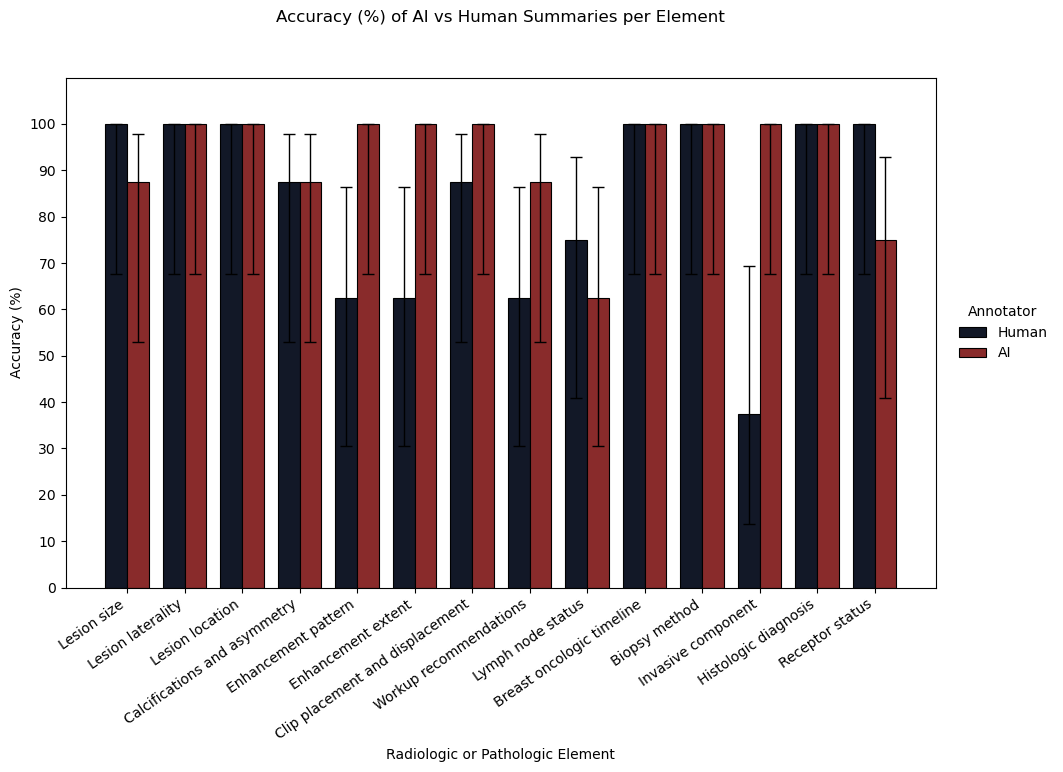

In [ ]:
# Side-by-side bar plot comparing human and AI accuracies across elements with 95% CIs
element_order = df_accuracy_tests['Element'].tolist()
plot_records = []
for _, row in df_accuracy_tests.iterrows():
    plot_records.extend([
        {
            'Element': row['Element'],
            'Annotator': 'Human',
            'Accuracy_pct': row['Human Accuracy'] * 100,
            'ci_low_pct': row['Human CI Low'] * 100,
            'ci_high_pct': row['Human CI High'] * 100,
        },
        {
            'Element': row['Element'],
            'Annotator': 'AI',
            'Accuracy_pct': row['AI Accuracy'] * 100,
            'ci_low_pct': row['AI CI Low'] * 100,
            'ci_high_pct': row['AI CI High'] * 100,
        },
    ])
plot_df = pd.DataFrame(plot_records)
plot_df['Element'] = pd.Categorical(plot_df['Element'], categories=element_order, ordered=True)
plot_df['Annotator'] = pd.Categorical(plot_df['Annotator'], categories=['Human', 'AI'], ordered=True)
plot_df_sorted = plot_df.sort_values(['Annotator', 'Element']).reset_index(drop=True)
max_ci_pct = plot_df['ci_high_pct'].max()
fig, ax = plt.subplots(figsize=(12.5, 8.5))
sns.barplot(
    data=plot_df,
    x='Element',
    y='Accuracy_pct',
    hue='Annotator',
    palette=['#0f172a', '#991b1b'],
    edgecolor='black',
    linewidth=0.8,
    width=0.75,
    ax=ax,
    order=element_order,
    hue_order=['Human', 'AI'],
    errorbar=None,
 )
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Radiologic or Pathologic Element')
y_max = max(110, max_ci_pct + 10)
ax.set_ylim(0, y_max)
ax.set_yticks(np.arange(0, 101, 10))
ax.margins(y=0.06)
ax.set_title('Accuracy (%) of AI vs Human Summaries per Element', pad=40)
plt.xticks(rotation=35, ha='right')
for patch, record in zip(ax.patches, plot_df_sorted.itertuples(index=False)):
    center = patch.get_x() + patch.get_width() / 2
    err_low = max(record.Accuracy_pct - record.ci_low_pct, 0)
    err_high = max(record.ci_high_pct - record.Accuracy_pct, 0)
    ax.errorbar(
        center,
        record.Accuracy_pct,
        yerr=[[err_low], [err_high]],
        color='black',
        capsize=4,
        linewidth=1,
        fmt='none',
        zorder=5,
    )
legend = ax.legend(
    title='Annotator',
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    ncol=1,
 )
fig.tight_layout(rect=[0, 0.03, 0.86, 0.95])
plt.show()

Accuracy metric stratified by radiologic vs pathologic elements

Accuracy metric stratified by case complexity